# Experiment 1: Perceptron Learning Implementation
** Roll Number:** `CH.SC.U4AIE24015`  



### Implementation and Training


Student Roll Number: CH.SC.U4AIE24015
Experiment 1: Perceptron Learning Algorithm for AND Gate
[Roll No: CH.SC.U4AIE24015] Epoch  1 | Weight: [0.1 0.1] | Bias: 0.00 | Errors: 2
[Roll No: CH.SC.U4AIE24015] Epoch  2 | Weight: [0.2 0.1] | Bias: -0.10 | Errors: 3
[Roll No: CH.SC.U4AIE24015] Epoch  3 | Weight: [0.2 0.1] | Bias: -0.20 | Errors: 3
[Roll No: CH.SC.U4AIE24015] Epoch  4 | Weight: [0.2 0.1] | Bias: -0.20 | Errors: 0
--> Converged successfully at epoch 4!

--------------------------------------------------
Final Evaluation [Roll No: CH.SC.U4AIE24015]:
Input: [0 0] -> True: 0, Predicted: 0
Input: [0 1] -> True: 0, Predicted: 0
Input: [1 0] -> True: 0, Predicted: 0
Input: [1 1] -> True: 1, Predicted: 1
--------------------------------------------------


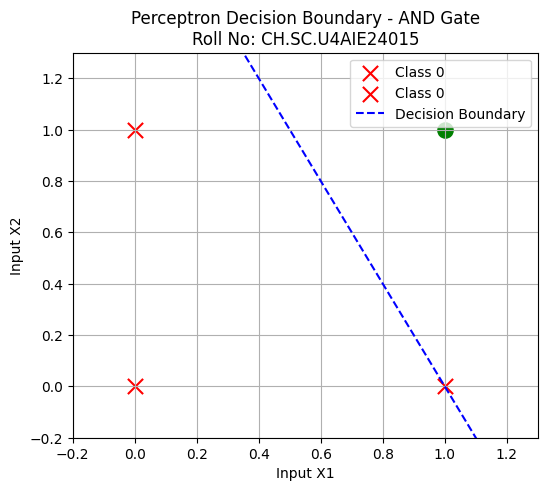

In [1]:
# Experiment 1: Perceptron Learning Implementation
# File: Exp_01_Perceptron_Learning.ipynb
# Student Roll Number: CH.SC.U4AIE24015

import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("Student Roll Number: CH.SC.U4AIE24015")
print("Experiment 1: Perceptron Learning Algorithm for AND Gate")
print("=" * 60)

# Binary AND gate dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

# Perceptron Implementation
class Perceptron:
    def __init__(self, learning_rate=0.1, max_epochs=20):
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.weights = None
        self.bias = 0.0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(1, self.max_epochs + 1):
            errors = 0
            for xi, target in zip(X, y):
                linear_output = np.dot(xi, self.weights) + self.bias
                prediction = 1 if linear_output >= 0 else 0
                update = self.lr * (target - prediction)
                self.weights += update * xi
                self.bias += update
                if update != 0.0:
                    errors += 1
            print(f"[Roll No: CH.SC.U4AIE24015] Epoch {epoch:2d} | Weight: {self.weights} | Bias: {self.bias:.2f} | Errors: {errors}")
            if errors == 0:
                print(f"--> Converged successfully at epoch {epoch}!")
                break

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)

# Train Perceptron
p = Perceptron(learning_rate=0.1, max_epochs=20)
p.fit(X, y)

# Predictions
preds = p.predict(X)
print("\n" + "-" * 50)
print(f"Final Evaluation [Roll No: CH.SC.U4AIE24015]:")
for sample, target, pred in zip(X, y, preds):
    print(f"Input: {sample} -> True: {target}, Predicted: {pred}")
print("-" * 50)

# Visualization
plt.figure(figsize=(6, 5))
for i, label in enumerate(y):
    marker = 'o' if label == 1 else 'x'
    color = 'green' if label == 1 else 'red'
    plt.scatter(X[i, 0], X[i, 1], c=color, marker=marker, s=120, label=f"Class {label}" if i < 2 else "")

# Decision boundary: w0*x0 + w1*x1 + b = 0 => x1 = -(w0*x0 + b) / w1
x_vals = np.linspace(-0.5, 1.5, 100)
if p.weights[1] != 0:
    y_vals = -(p.weights[0] * x_vals + p.bias) / p.weights[1]
    plt.plot(x_vals, y_vals, 'b--', label='Decision Boundary')

plt.xlim(-0.2, 1.3)
plt.ylim(-0.2, 1.3)
plt.title(f"Perceptron Decision Boundary - AND Gate\nRoll No: CH.SC.U4AIE24015")
plt.xlabel("Input X1")
plt.ylabel("Input X2")
plt.grid(True)
plt.legend()
plt.show()
